In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
df= pd.read_csv('../data/Daily Household Transactions.csv')

In [3]:
df

,Date,Mode,Category,Subcategory,Note,Amount,Income/Expense,Currency
0,20/09/2018 12:04:08,Cash,Transportation,Train,2 Place 5 to Place 0,30.0,Expense,INR
1,20/09/2018 12:03:15,Cash,Food,snacks,Idli medu Vada mix 2 plates,60.0,Expense,INR
2,19/09/2018,Saving Bank account 1,subscription,Netflix,1 month subscription,199.0,Expense,INR
3,17/09/2018 23:41:17,Saving Bank account 1,subscription,Mobile Service Provider,Data booster pack,19.0,Expense,INR
4,16/09/2018 17:15:08,Cash,Festivals,Ganesh Pujan,Ganesh idol,251.0,Expense,INR
...,...,...,...,...,...,...,...,...
2456,1/1/2015,Cash,Transportation,NaN,share jeep - Place T base to top,20.0,Expense,INR
2457,1/1/2015,Cash,Transportation,NaN,share auto - Place H to Place T base,20.0,Expense,INR
2458,1/1/2015,Cash,Transportation,NaN,bus - brc to Place H,30.0,Expense,INR
2459,1/1/2015,Cash,Food,NaN,tea,10.0,Expense,INR


In [4]:
df.shape

(2461, 8)

In [5]:
df.columns


Index(['Date', 'Mode', 'Category', 'Subcategory', 'Note', 'Amount',
       'Income/Expense', 'Currency'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2461 entries, 0 to 2460
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            2461 non-null   str    
 1   Mode            2461 non-null   str    
 2   Category        2461 non-null   str    
 3   Subcategory     1826 non-null   str    
 4   Note            1940 non-null   str    
 5   Amount          2461 non-null   float64
 6   Income/Expense  2461 non-null   str    
 7   Currency        2461 non-null   str    
dtypes: float64(1), str(7)
memory usage: 153.9 KB


In [7]:
df.isnull().sum()

Date                0
Mode                0
Category            0
Subcategory       635
Note              521
Amount              0
Income/Expense      0
Currency            0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(9)

In [9]:
df.drop_duplicates(inplace=True)

In [10]:
df.duplicated().sum()
df

,Date,Mode,Category,Subcategory,Note,Amount,Income/Expense,Currency
0,20/09/2018 12:04:08,Cash,Transportation,Train,2 Place 5 to Place 0,30.0,Expense,INR
1,20/09/2018 12:03:15,Cash,Food,snacks,Idli medu Vada mix 2 plates,60.0,Expense,INR
2,19/09/2018,Saving Bank account 1,subscription,Netflix,1 month subscription,199.0,Expense,INR
3,17/09/2018 23:41:17,Saving Bank account 1,subscription,Mobile Service Provider,Data booster pack,19.0,Expense,INR
4,16/09/2018 17:15:08,Cash,Festivals,Ganesh Pujan,Ganesh idol,251.0,Expense,INR
...,...,...,...,...,...,...,...,...
2456,1/1/2015,Cash,Transportation,NaN,share jeep - Place T base to top,20.0,Expense,INR
2457,1/1/2015,Cash,Transportation,NaN,share auto - Place H to Place T base,20.0,Expense,INR
2458,1/1/2015,Cash,Transportation,NaN,bus - brc to Place H,30.0,Expense,INR
2459,1/1/2015,Cash,Food,NaN,tea,10.0,Expense,INR


In [11]:
df.describe()

,Amount
count,2452.000000
mean,2757.976664
std,12542.057491
min,2.000000
25%,35.000000
50%,100.000000
75%,784.500000
max,250000.000000


In [12]:
df['Category'].unique()

<StringArray>
[           'Transportation',                      'Food',
              'subscription',                 'Festivals',
                     'Other',          'Small Cap fund 2',
          'Small cap fund 1',                    'Family',
      'Equity Mutual Fund E',                   'Apparel',
     'Public Provident Fund',     'Saving Bank account 1',
                      'Gift',                    'Salary',
                 'Household', 'Dividend earned on Shares',
                  'Interest',            'Life Insurance',
                    'Beauty',                    'Health',
            'Money transfer',                      'maid',
                   'Culture',                'Tax refund',
                   'Tourism',              'Share Market',
          'Self-development',       'Amazon pay cashback',
                 'Education',                     'scrap',
                'Petty cash',                 'Documents',
               'Gpay Reward',             

In [13]:
df['Date'].unique()

<StringArray>
['20/09/2018 12:04:08', '20/09/2018 12:03:15',          '19/09/2018',
 '17/09/2018 23:41:17', '16/09/2018 17:15:08', '15/09/2018 06:34:17',
 '14/09/2018 05:39:17', '13/09/2018 21:35:15', '13/09/2018 21:01:47',
 '13/09/2018 21:01:32',
 ...
           '10/1/2015',            '9/1/2015',            '8/1/2015',
            '7/1/2015',            '6/1/2015',            '5/1/2015',
            '4/1/2015',            '3/1/2015',            '2/1/2015',
            '1/1/2015']
Length: 1611, dtype: str

In [14]:
income = df[df["Income/Expense"]=="Income"][["Income/Expense","Amount"]].sort_values(by="Amount",ascending=False)
print(income)

     Income/Expense    Amount
660          Income  113376.0
661          Income  106875.0
866          Income   78298.0
2061         Income   77335.0
1997         Income   70806.0
...             ...       ...
1015         Income       5.0
1739         Income       5.0
1776         Income       5.0
1075         Income       3.0
600          Income       2.0

[125 rows x 2 columns]


In [15]:
df["Income/Expense"].unique()

<StringArray>
['Expense', 'Transfer-Out', 'Income']
Length: 3, dtype: str

In [16]:
expense = df[df["Income/Expense"]=="Expense"][["Income/Expense","Amount"]].sort_values(by="Amount",ascending=False)
print(expense)

     Income/Expense    Amount
1710        Expense  100000.0
608         Expense   50000.0
2086        Expense   50000.0
582         Expense   43000.0
1080        Expense   43000.0
...             ...       ...
2003        Expense       5.0
469         Expense       4.0
1268        Expense       3.0
1789        Expense       2.0
160         Expense       2.0

[2173 rows x 2 columns]


In [17]:
transfer_out = df[df["Income/Expense"]=='Transfer-Out'][["Income/Expense","Amount"]].sort_values(by="Amount",ascending=False)
print(transfer_out)

     Income/Expense     Amount
687    Transfer-Out  250000.00
1225   Transfer-Out  200000.00
688    Transfer-Out  150000.00
904    Transfer-Out  150000.00
765    Transfer-Out  100000.00
...             ...        ...
1288   Transfer-Out     100.00
1207   Transfer-Out     100.00
592    Transfer-Out      97.14
773    Transfer-Out      77.33
448    Transfer-Out      42.88

[154 rows x 2 columns]


In [18]:
df["Amount"].max()

np.float64(250000.0)

In [19]:
df["Amount"].min()

np.float64(2.0)

In [20]:
(df["Amount"]<0).any()

np.False_

##DISCOVERED TILL NOW
Rows:              2461
Columns:           8

Missing values-
Subcategory:       635
Note:              521

Duplicates:        9
(removed duplicates)

Date:
❌ stored as string
❌ inconsistent date/time formats

Transaction types:
Expense:           2173
Income:             125
Transfer-Out:       154

Amount:
Min:                ₹2
Max:                ₹250,000
Negative values:    None

Distribution:
Median:             ₹100
Mean:               ~₹2,758
→ highly skewed

In [21]:
df["Currency"].unique()

<StringArray>
['INR']
Length: 1, dtype: str

In [22]:



df.sort_values(by='Amount',ascending=False).head(10)

,Date,Mode,Category,Subcategory,Note,Amount,Income/Expense,Currency
687,26/12/2017 21:55:12,Saving Bank account 1,Fixed Deposit,NaN,NaN,250000.0,Transfer-Out,INR
1225,27/06/2017 10:00:50,Saving Bank account 1,Fixed Deposit,NaN,New FD opened for 3 years,200000.0,Transfer-Out,INR
904,10/10/2017,Saving Bank account 1,Share Market,NaN,Stock market,150000.0,Transfer-Out,INR
688,26/12/2017 21:50:33,Fixed Deposit,Saving Bank account 1,NaN,NaN,150000.0,Transfer-Out,INR
660,4/1/2018,Equity Mutual Fund A,Maturity amount,NaN,SIP Redemption,113376.0,Income,INR
661,4/1/2018,Equity Mutual Fund D,Maturity amount,NaN,SIP Redemption,106875.0,Income,INR
765,1/12/2017,Share Market Trading,Saving Bank account 1,NaN,Fund Withdrawal,100000.0,Transfer-Out,INR
1710,1/1/2017,Saving Bank account 1,Money transfer,NaN,NaN,100000.0,Expense,INR
1171,12/7/2017,Saving Bank account 1,Equity Mutual Fund B,NaN,NaN,100000.0,Transfer-Out,INR
866,1/11/2017,Saving Bank account 1,Salary,NaN,From workplace,78298.0,Income,INR


In [23]:
df.sort_values(by='Amount',ascending=True).head(10)

,Date,Mode,Category,Subcategory,Note,Amount,Income/Expense,Currency
600,20/01/2018 23:30:27,Saving Bank account 1,Amazon pay cashback,NaN,NaN,2.0,Income,INR
160,7/7/2018,Credit Card,Food,Lunch,At restaurant,2.0,Expense,INR
1789,19/11/2016 12:12:00,Cash,Food,chocolate,poppins,2.0,Expense,INR
1075,10/8/2017,Saving Bank account 1,Gpay Reward,NaN,NaN,3.0,Income,INR
1268,6/6/2017,Cash,Education,Stationary,Print out,3.0,Expense,INR
469,6/3/2018,Saving Bank account 1,Education,Stationary,Xerox,4.0,Expense,INR
1013,31/08/2017 10:22:07,Cash,Household,Kirana,Janeyu,5.0,Expense,INR
786,27/11/2017 13:38:55,Cash,Transportation,Train,1 Place 0 to Place 6,5.0,Expense,INR
979,12/9/2017,Saving Bank account 1,Gpay Reward,NaN,NaN,5.0,Income,INR
1015,31/08/2017 06:56:51,Saving Bank account 1,Gpay Reward,NaN,NaN,5.0,Income,INR


In [24]:
df['Mode'].value_counts()

Mode
Saving Bank account 1    1215
Cash                     1045
Credit Card               162
Equity Mutual Fund B       11
Share Market Trading        5
Saving Bank account 2       5
Recurring Deposit           3
Debit Card                  2
Equity Mutual Fund C        1
Equity Mutual Fund A        1
Equity Mutual Fund D        1
Fixed Deposit               1
Name: count, dtype: int64

In [25]:
df['Category'].value_counts()

Category
Food                         906
Transportation               307
Household                    176
subscription                 143
Other                        126
Investment                   101
Health                        94
Family                        71
Apparel                       47
Salary                        43
Money transfer                43
Recurring Deposit             41
Gift                          30
Public Provident Fund         29
Equity Mutual Fund E          22
Beauty                        22
Gpay Reward                   21
Education                     18
Saving Bank account 1         17
maid                          17
Festivals                     16
Equity Mutual Fund A          14
Equity Mutual Fund F          13
Dividend earned on Shares     12
Interest                      12
Culture                       11
Small Cap fund 2              10
Small cap fund 1              10
Share Market                   8
Life Insurance                 7
M

In [26]:
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True, format="mixed")

In [27]:
df["Date"].min()

Timestamp('2015-01-01 00:00:00')

In [28]:
df["Date"].max()

Timestamp('2018-09-20 12:04:08')

In [29]:
df["Transaction_Date"] = df["Date"].dt.date
df["Transaction_Time"] = df["Date"].dt.time

df.drop(columns=["Date"], inplace=True)

In [30]:
df

,Mode,Category,Subcategory,Note,Amount,Income/Expense,Currency,Transaction_Date,Transaction_Time
0,Cash,Transportation,Train,2 Place 5 to Place 0,30.0,Expense,INR,2018-09-20,12:04:08
1,Cash,Food,snacks,Idli medu Vada mix 2 plates,60.0,Expense,INR,2018-09-20,12:03:15
2,Saving Bank account 1,subscription,Netflix,1 month subscription,199.0,Expense,INR,2018-09-19,00:00:00
3,Saving Bank account 1,subscription,Mobile Service Provider,Data booster pack,19.0,Expense,INR,2018-09-17,23:41:17
4,Cash,Festivals,Ganesh Pujan,Ganesh idol,251.0,Expense,INR,2018-09-16,17:15:08
...,...,...,...,...,...,...,...,...,...
2456,Cash,Transportation,NaN,share jeep - Place T base to top,20.0,Expense,INR,2015-01-01,00:00:00
2457,Cash,Transportation,NaN,share auto - Place H to Place T base,20.0,Expense,INR,2015-01-01,00:00:00
2458,Cash,Transportation,NaN,bus - brc to Place H,30.0,Expense,INR,2015-01-01,00:00:00
2459,Cash,Food,NaN,tea,10.0,Expense,INR,2015-01-01,00:00:00


In [31]:
df.info()

<class 'pandas.DataFrame'>
Index: 2452 entries, 0 to 2460
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Mode              2452 non-null   str    
 1   Category          2452 non-null   str    
 2   Subcategory       1823 non-null   str    
 3   Note              1940 non-null   str    
 4   Amount            2452 non-null   float64
 5   Income/Expense    2452 non-null   str    
 6   Currency          2452 non-null   str    
 7   Transaction_Date  2452 non-null   object 
 8   Transaction_Time  2452 non-null   object 
dtypes: float64(1), object(2), str(6)
memory usage: 191.6+ KB


## STANDARIZE COLUMN NAMES

In [32]:
df.columns

Index(['Mode', 'Category', 'Subcategory', 'Note', 'Amount', 'Income/Expense',
       'Currency', 'Transaction_Date', 'Transaction_Time'],
      dtype='str')

In [33]:
df.columns = df.columns.str.lower()

In [34]:
df

,mode,category,subcategory,note,amount,income/expense,currency,transaction_date,transaction_time
0,Cash,Transportation,Train,2 Place 5 to Place 0,30.0,Expense,INR,2018-09-20,12:04:08
1,Cash,Food,snacks,Idli medu Vada mix 2 plates,60.0,Expense,INR,2018-09-20,12:03:15
2,Saving Bank account 1,subscription,Netflix,1 month subscription,199.0,Expense,INR,2018-09-19,00:00:00
3,Saving Bank account 1,subscription,Mobile Service Provider,Data booster pack,19.0,Expense,INR,2018-09-17,23:41:17
4,Cash,Festivals,Ganesh Pujan,Ganesh idol,251.0,Expense,INR,2018-09-16,17:15:08
...,...,...,...,...,...,...,...,...,...
2456,Cash,Transportation,NaN,share jeep - Place T base to top,20.0,Expense,INR,2015-01-01,00:00:00
2457,Cash,Transportation,NaN,share auto - Place H to Place T base,20.0,Expense,INR,2015-01-01,00:00:00
2458,Cash,Transportation,NaN,bus - brc to Place H,30.0,Expense,INR,2015-01-01,00:00:00
2459,Cash,Food,NaN,tea,10.0,Expense,INR,2015-01-01,00:00:00


In [35]:
df = df.rename(columns={"income/expense":"income_expense"})

In [36]:
df

,mode,category,subcategory,note,amount,income_expense,currency,transaction_date,transaction_time
0,Cash,Transportation,Train,2 Place 5 to Place 0,30.0,Expense,INR,2018-09-20,12:04:08
1,Cash,Food,snacks,Idli medu Vada mix 2 plates,60.0,Expense,INR,2018-09-20,12:03:15
2,Saving Bank account 1,subscription,Netflix,1 month subscription,199.0,Expense,INR,2018-09-19,00:00:00
3,Saving Bank account 1,subscription,Mobile Service Provider,Data booster pack,19.0,Expense,INR,2018-09-17,23:41:17
4,Cash,Festivals,Ganesh Pujan,Ganesh idol,251.0,Expense,INR,2018-09-16,17:15:08
...,...,...,...,...,...,...,...,...,...
2456,Cash,Transportation,NaN,share jeep - Place T base to top,20.0,Expense,INR,2015-01-01,00:00:00
2457,Cash,Transportation,NaN,share auto - Place H to Place T base,20.0,Expense,INR,2015-01-01,00:00:00
2458,Cash,Transportation,NaN,bus - brc to Place H,30.0,Expense,INR,2015-01-01,00:00:00
2459,Cash,Food,NaN,tea,10.0,Expense,INR,2015-01-01,00:00:00


In [37]:
df.info()

<class 'pandas.DataFrame'>
Index: 2452 entries, 0 to 2460
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   mode              2452 non-null   str    
 1   category          2452 non-null   str    
 2   subcategory       1823 non-null   str    
 3   note              1940 non-null   str    
 4   amount            2452 non-null   float64
 5   income_expense    2452 non-null   str    
 6   currency          2452 non-null   str    
 7   transaction_date  2452 non-null   object 
 8   transaction_time  2452 non-null   object 
dtypes: float64(1), object(2), str(6)
memory usage: 191.6+ KB


In [38]:
df.isnull().sum()

mode                  0
category              0
subcategory         629
note                512
amount                0
income_expense        0
currency              0
transaction_date      0
transaction_time      0
dtype: int64

In [39]:
df["transaction_date"] = pd.to_datetime(df["transaction_date"],dayfirst=True)

In [40]:
df["transaction_date"].isna().sum()

np.int64(0)

In [41]:
df["transaction_time"] = pd.to_datetime(df["transaction_time"],format= "%H:%M:%S").dt.time

In [42]:
df.head()

,mode,category,subcategory,note,amount,income_expense,currency,transaction_date,transaction_time
0,Cash,Transportation,Train,2 Place 5 to Place 0,30.0,Expense,INR,2018-09-20,12:04:08
1,Cash,Food,snacks,Idli medu Vada mix 2 plates,60.0,Expense,INR,2018-09-20,12:03:15
2,Saving Bank account 1,subscription,Netflix,1 month subscription,199.0,Expense,INR,2018-09-19,00:00:00
3,Saving Bank account 1,subscription,Mobile Service Provider,Data booster pack,19.0,Expense,INR,2018-09-17,23:41:17
4,Cash,Festivals,Ganesh Pujan,Ganesh idol,251.0,Expense,INR,2018-09-16,17:15:08


In [43]:
df["transaction_date"].dtype

dtype('<M8[s]')

In [44]:
type(df["transaction_time"].iloc[0])

datetime.time

In [45]:
df[df["subcategory"].isna()][["category","note"]].head(10)

,category,note
8,Other,HBR 2 Months subscription
10,Small Cap fund 2,NaN
11,Small cap fund 1,NaN
14,Other,From Family
19,Equity Mutual Fund E,NaN
28,Public Provident Fund,NaN
29,Saving Bank account 1,NaN
31,Gift,farewell contribution
33,Salary,From workplace
40,Dividend earned on Shares,Astral Stocks


In [46]:
df[df["note"].isna()][["category","note"]].head(10)

,category,note
10,Small Cap fund 2,NaN
11,Small cap fund 1,NaN
17,Family,NaN
19,Equity Mutual Fund E,NaN
27,Family,NaN
28,Public Provident Fund,NaN
29,Saving Bank account 1,NaN
30,Family,NaN
50,Food,NaN
57,Life Insurance,NaN


In [47]:
df[["subcategory", "note"]].apply(
    lambda col: col.astype("string").str.strip().eq("").sum()
)

subcategory    0
note           0
dtype: int64

In [48]:
df[["subcategory","note"]].isna().sum()

subcategory    629
note           512
dtype: int64

In [49]:
for col in ["subcategory", "note"]:
    df[col] = df[col].astype("string").str.strip()
    df[col] = df[col].replace("", pd.NA).fillna("Unknown")

In [50]:
df[["subcategory","note"]].isna().sum()

subcategory    0
note           0
dtype: int64

## FINAL DATA CLEANING

In [51]:
df_clean= df.copy()

In [52]:
text_columns = [
    "mode","category","subcategory","note","income_expense","currency"
]
for col in text_columns:
    df_clean[col]=df_clean[col].astype("string").str.strip()

In [53]:
for col in ["category","mode"]:
    df_clean[col] = df_clean[col].str.title()

In [54]:
for col in ["subcategory","note"]:
    df_clean[col]=(
        df_clean[col].replace("",pd.NA).fillna("Unknown")
    )

In [55]:
type_mapping = {
    "expense":"Expense",
    "income":"Income",
    "transfer-out":"Transfer-out"
}

df_clean["income_expense"] = (
    df_clean["income_expense"].str.casefold().map(type_mapping).fillna(df_clean["income_expense"])
)

In [56]:
df_clean["currency"] = df_clean["currency"].str.upper()

In [57]:
df_clean["amount"] = pd.to_numeric(
    df_clean["amount"],errors="coerce"
)

In [58]:
print("Missing dates: ",df_clean["transaction_date"].isna().sum())
print("Missing amount: ",df_clean["amount"].isna().sum())
print("Negative amount: ",(df_clean["amount"]<0).isna().sum())
print("Duplicate rows: ",df_clean.duplicated().sum())
print("\nTransaction types:")
print(df_clean["income_expense"].value_counts())
print("\nCurrencies:")
print(df_clean["currency"].value_counts())

Missing dates:  0
Missing amount:  0
Negative amount:  0
Duplicate rows:  0

Transaction types:
income_expense
Expense         2173
Transfer-out     154
Income           125
Name: count, dtype: int64

Currencies:
currency
INR    2452
Name: count, dtype: Int64


## Visualization

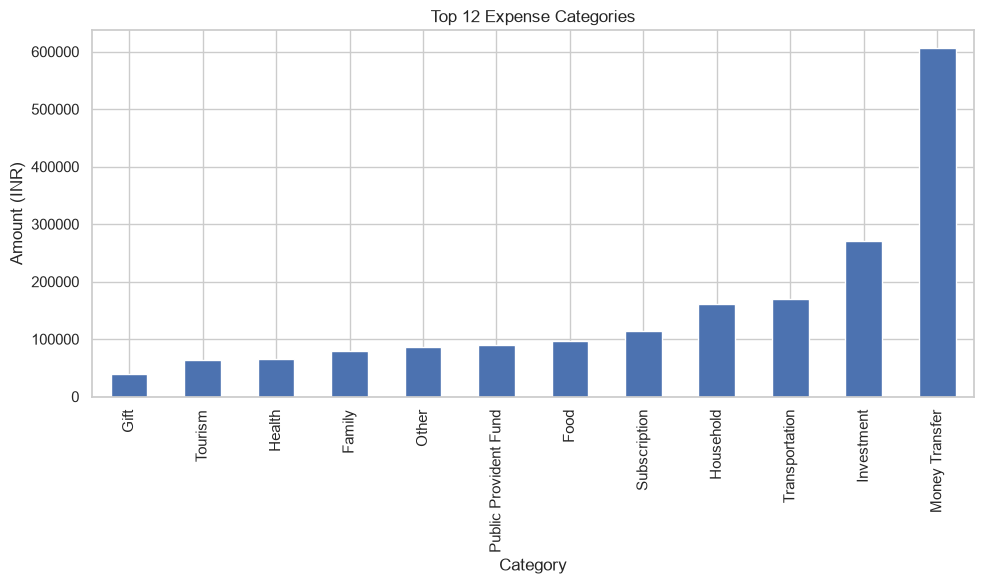

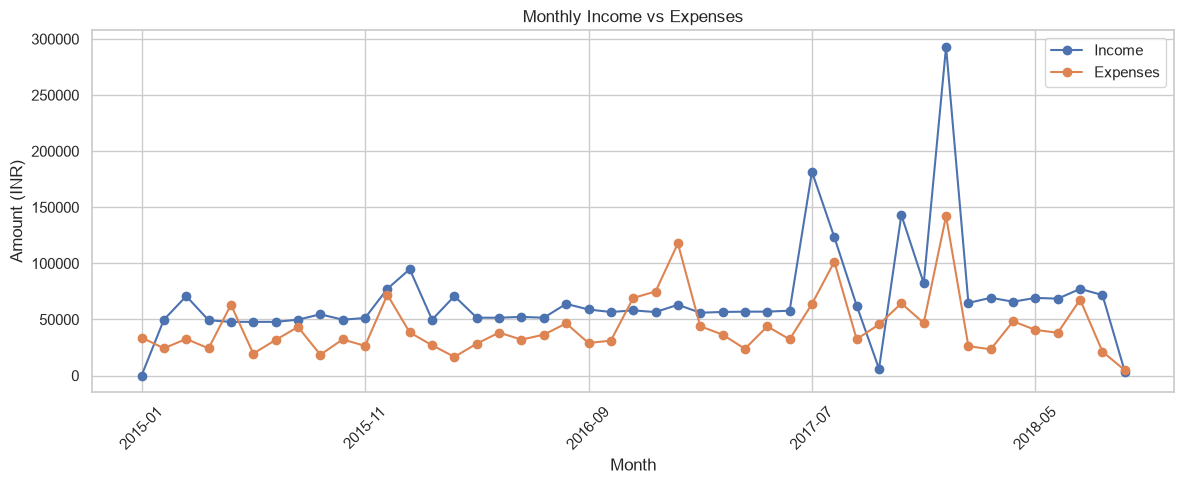

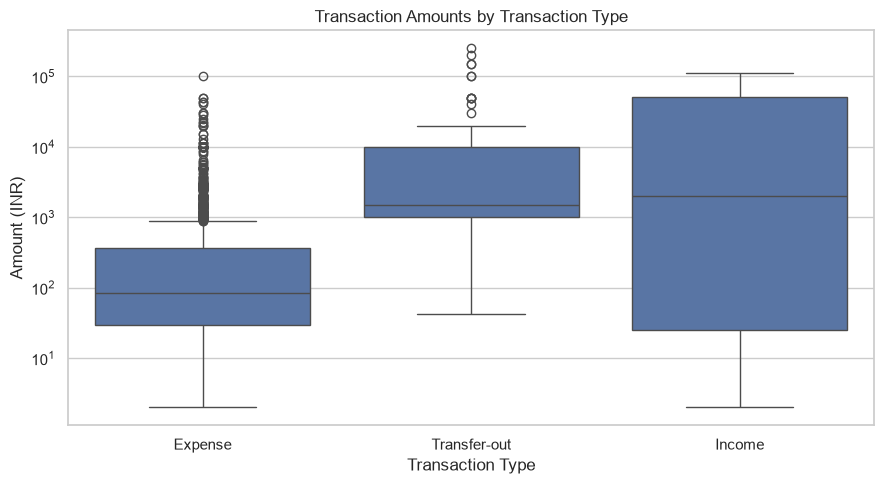

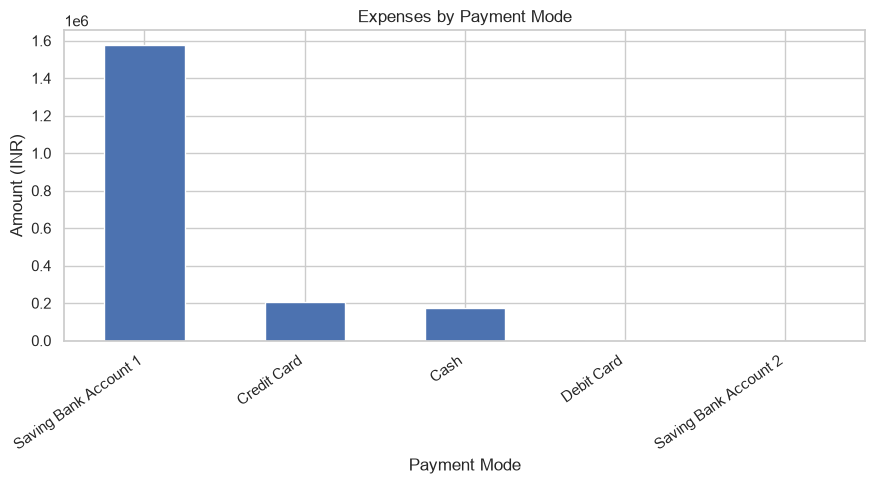

Total income: 3042397.3499999996
Total expenses: 1955380.5300000003
Net income minus expenses: 1087016.8199999994
Transfer-Out total: 0.0


In [66]:

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Analyze only genuine income and expense transactions.
# Transfer-Out is excluded to avoid treating transfers as spending.
expenses = df_clean[df_clean["income_expense"] == "Expense"].copy()
income = df_clean[df_clean["income_expense"] == "Income"].copy()

# Chart 1: Spending by category
category_spending = (
    expenses.groupby("category")["amount"]
    .sum()
    .sort_values(ascending=False)
    .head(12)
    .sort_values()
)

plt.figure(figsize=(10, 6))
category_spending.plot(kind="bar")
plt.title("Top 12 Expense Categories")
plt.xlabel("Category")
plt.ylabel("Amount (INR)")
plt.tight_layout()
plt.show()

# Chart 2: Monthly income vs expenses
monthly_income = (
    income.groupby(income["transaction_date"].dt.to_period("M"))["amount"]
    .sum()
)
monthly_expenses = (
    expenses.groupby(expenses["transaction_date"].dt.to_period("M"))["amount"]
    .sum()
)

monthly = pd.concat(
    [monthly_income.rename("Income"),
     monthly_expenses.rename("Expenses")],
    axis=1
).fillna(0).sort_index()

monthly.index = monthly.index.astype(str)

plt.figure(figsize=(12, 5))
monthly.plot(ax=plt.gca(), marker="o")
plt.title("Monthly Income vs Expenses")
plt.xlabel("Month")
plt.ylabel("Amount (INR)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Chart 3: Distribution of transaction amounts by type
plt.figure(figsize=(9, 5))
sns.boxplot(
    data=df_clean,
    x="income_expense",
    y="amount"
)
plt.title("Transaction Amounts by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Amount (INR)")
plt.yscale("log")
plt.tight_layout()
plt.show()

# Chart 4: Expense payment modes
mode_spending = (
    expenses.groupby("mode")["amount"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))
mode_spending.plot(kind="bar")
plt.title("Expenses by Payment Mode")
plt.xlabel("Payment Mode")
plt.ylabel("Amount (INR)")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

print("Total income:", income["amount"].sum())
print("Total expenses:", expenses["amount"].sum())
print("Net income minus expenses:",
      income["amount"].sum() - expenses["amount"].sum())
print("Transfer-Out total:",
      df_clean.loc[
          df_clean["income_expense"] == "Transfer-Out", "amount"
      ].sum())
